In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#get the data
url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/ISLR/Weekly.csv"

Weekly = pd.read_csv(url)

Weekly.head()

,rownames,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,2,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,3,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,4,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,5,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [3]:
Weekly.info()

<class 'pandas.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   rownames   1089 non-null   int64  
 1   Year       1089 non-null   int64  
 2   Lag1       1089 non-null   float64
 3   Lag2       1089 non-null   float64
 4   Lag3       1089 non-null   float64
 5   Lag4       1089 non-null   float64
 6   Lag5       1089 non-null   float64
 7   Volume     1089 non-null   float64
 8   Today      1089 non-null   float64
 9   Direction  1089 non-null   str    
dtypes: float64(7), int64(2), str(1)
memory usage: 85.2 KB


In [4]:
Weekly.describe()

,rownames,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,545.000000,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,314.511526,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1.000000,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,273.000000,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,545.000000,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,817.000000,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,1089.000000,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


In [5]:
Weekly.corr(numeric_only=True)

,rownames,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
rownames,1.000000,0.998863,-0.031577,-0.033129,-0.030420,-0.030935,-0.030382,0.842095,-0.031183
Year,0.998863,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460
Lag1,-0.031577,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032
Lag2,-0.033129,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167
Lag3,-0.030420,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244
Lag4,-0.030935,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826
Lag5,-0.030382,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013
Volume,0.842095,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078
Today,-0.031183,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000


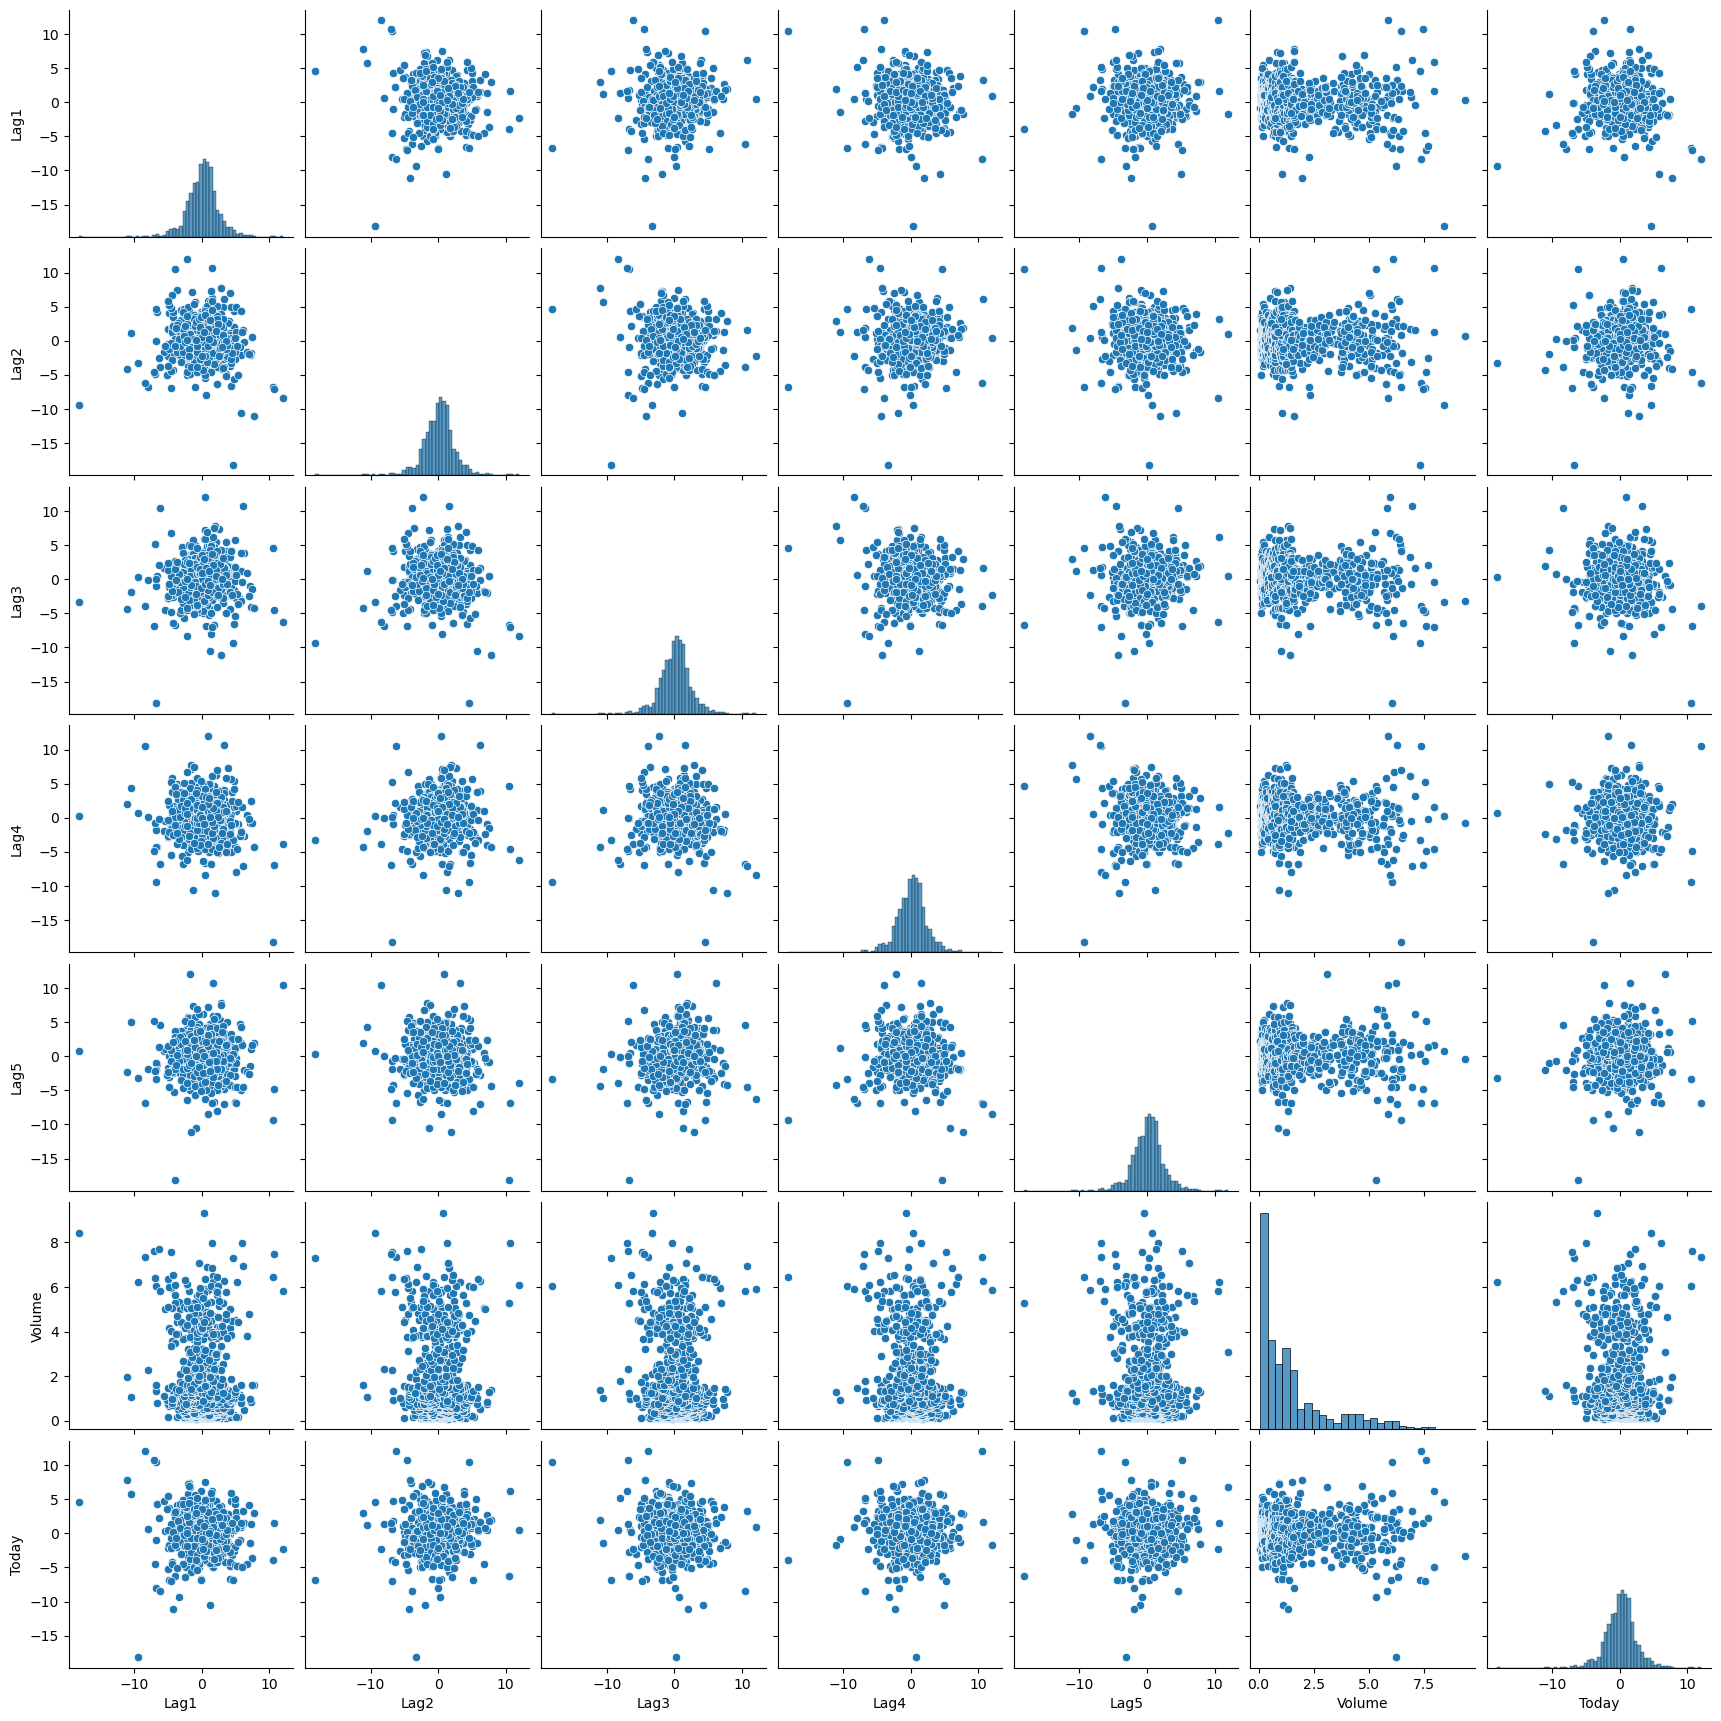

In [16]:
#13.a
sns.pairplot(
    Weekly,
    vars=["Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume", "Today"]
)

plt.show()

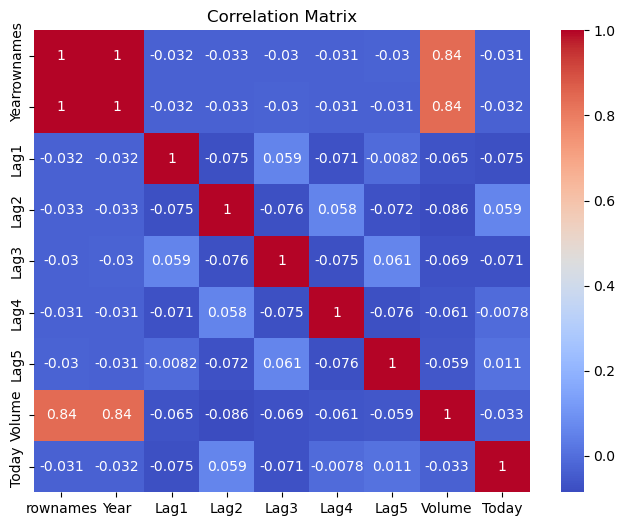

In [7]:
plt.figure(figsize=(8,6))

sns.heatmap(
    Weekly.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

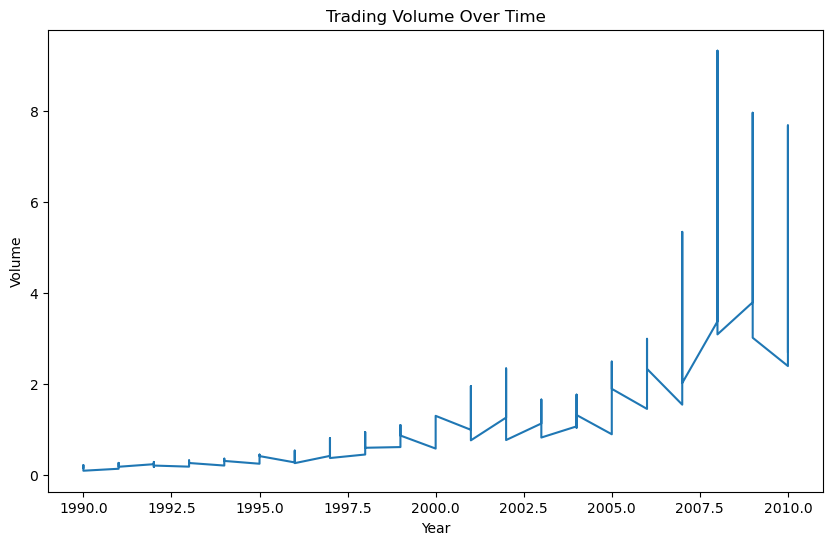

In [8]:
plt.figure(figsize=(10,6))

plt.plot(
    Weekly["Year"],
    Weekly["Volume"]
)

plt.xlabel("Year")
plt.ylabel("Volume")
plt.title("Trading Volume Over Time")

plt.show()

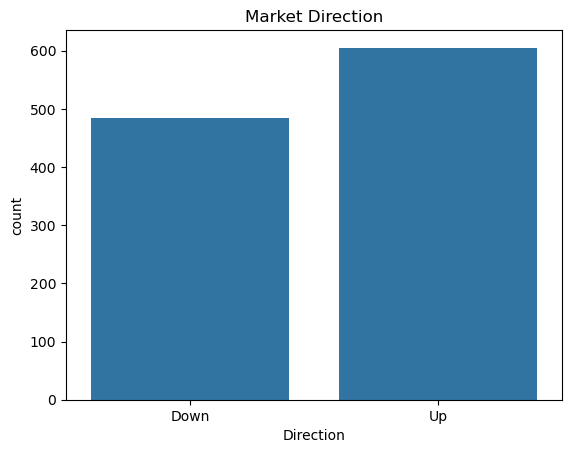

In [9]:
sns.countplot(
    x="Direction",
    data=Weekly
)

plt.title("Market Direction")

plt.show()

The Weekly dataset contains weekly stock market returns and trading information from 1990 through 2010. Numerical summaries and graphical analysis were used to explore relationships among the variables. Correlation analysis showed that most lag variables had relatively weak relationships with one another and with Today’s returns. Scatterplot matrices also suggested little evidence of strong linear relationships among the lag predictors.

The most noticeable pattern in the dataset was the steady increase in trading Volume over time. The plot of Volume versus Year demonstrated a strong upward trend, indicating that market trading activity increased substantially during the observed period. Additionally, the distribution of the Direction variable appeared relatively balanced between Up and Down market movements. Overall, the exploratory analysis suggested that predicting market direction may be difficult because the lagged return variables exhibit limited predictive structure.

In [11]:
#Question 13.b
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [13]:
#Fit Logistic Regression
log_model = smf.glm(
    formula='Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume',
    data=Weekly,
    family=sm.families.Binomial()
).fit()

In [14]:
print(log_model.summary())

                          Generalized Linear Model Regression Results                           
Dep. Variable:     ['Direction[Down]', 'Direction[Up]']   No. Observations:                 1089
Model:                                              GLM   Df Residuals:                     1082
Model Family:                                  Binomial   Df Model:                            6
Link Function:                                    Logit   Scale:                          1.0000
Method:                                            IRLS   Log-Likelihood:                -743.18
Date:                                  Wed, 20 May 2026   Deviance:                       1486.4
Time:                                          08:10:01   Pearson chi2:                 1.09e+03
No. Iterations:                                       4   Pseudo R-squ. (CS):           0.009000
Covariance Type:                              nonrobust                                         
                 coef    std e

A logistic regression model was fit using Direction as the response variable and Lag1 through Lag5 along with Volume as predictors. Based on the regression output, only Lag2 appeared to be statistically significant at the 5% significance level, with a p-value of 0.030. All other predictors had p-values greater than 0.05 and therefore did not demonstrate strong evidence of association with market direction. The coefficient for Lag2 was negative, suggesting that higher returns two weeks prior were associated with a lower probability of the market moving Up in the current week. Although Lag2 was statistically significant, the model’s pseudo R2  value was very small, indicating limited overall predictive power for the logistic regression model.

In [17]:
#13.c - Generate Predicted Probabilities
pred_prob = log_model.predict(Weekly)

In [18]:
#Convert Probabilities into Predictions
pred_direction = np.where(pred_prob > 0.5, "Up", "Down")

In [19]:
#Create the Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    Weekly["Direction"],
    pred_direction
)

cm

array([[430,  54],
       [557,  48]])

In [20]:
#Display with Labels
cm_df = pd.DataFrame(
    cm,
    index=["Actual Down", "Actual Up"],
    columns=["Predicted Down", "Predicted Up"]
)

cm_df

,Predicted Down,Predicted Up
Actual Down,430,54
Actual Up,557,48


In [22]:
#Compute Accuracy
accuracy = np.mean(pred_direction == Weekly["Direction"])

print("Accuracy:", accuracy)

Accuracy: 0.4389348025711662


In [23]:
correct = np.sum(pred_direction == Weekly["Direction"])

print("Correct Predictions:", correct)
print("Total Observations:", len(Weekly))
print("Accuracy:", correct / len(Weekly))

Correct Predictions: 478
Total Observations: 1089
Accuracy: 0.4389348025711662


The confusion matrix was used to evaluate the classification performance of the logistic regression model. The model correctly classified 430 Down weeks and 48 Up weeks, resulting in an overall accuracy of approximately 43.9%. The confusion matrix indicates that the model strongly favored predicting Down market movements, as it classified 987 observations as Down compared to only 102 observations as Up.

The model made a large number of errors when predicting Up weeks, incorrectly classifying 557 actual Up observations as Down. This suggests that the logistic regression model performed poorly in distinguishing between market directions and exhibited a strong classification bias toward Down movements. Overall, the model demonstrated limited predictive accuracy and struggled to identify upward market trends effectively.

In [24]:
#13.d -Create Training and Test Sets
#training
train_data = Weekly[Weekly["Year"] <= 2008]
#test
test_data = Weekly[Weekly["Year"] > 2008]

In [25]:
#Fit Logistic Regression Using Lag2 Only
log_model_train = smf.glm(
    formula='Direction ~ Lag2',
    data=train_data,
    family=sm.families.Binomial()
).fit()

In [26]:
#Summary
print(log_model_train.summary())

                          Generalized Linear Model Regression Results                           
Dep. Variable:     ['Direction[Down]', 'Direction[Up]']   No. Observations:                  985
Model:                                              GLM   Df Residuals:                      983
Model Family:                                  Binomial   Df Model:                            1
Link Function:                                    Logit   Scale:                          1.0000
Method:                                            IRLS   Log-Likelihood:                -675.27
Date:                                  Wed, 20 May 2026   Deviance:                       1350.5
Time:                                          08:18:03   Pearson chi2:                     985.
No. Iterations:                                       4   Pseudo R-squ. (CS):           0.004221
Covariance Type:                              nonrobust                                         
                 coef    std e

In [27]:
#Predict Probabilities on Test Data
pred_prob_test = log_model_train.predict(test_data)

In [28]:
#Convert Probabilities to Predictions
pred_direction_test = np.where(
    pred_prob_test > 0.5,
    "Up",
    "Down"
)

In [29]:
#Create Confusion Matrix
from sklearn.metrics import confusion_matrix

cm_test = confusion_matrix(
    test_data["Direction"],
    pred_direction_test
)

cm_test

array([[34,  9],
       [56,  5]])

In [30]:
cm_test_df = pd.DataFrame(
    cm_test,
    index=["Actual Down", "Actual Up"],
    columns=["Predicted Down", "Predicted Up"]
)

cm_test_df

,Predicted Down,Predicted Up
Actual Down,34,9
Actual Up,56,5


In [31]:
#Compute Accuracy
accuracy_test = np.mean(
    pred_direction_test == test_data["Direction"]
)

print("Test Accuracy:", accuracy_test)

Test Accuracy: 0.375


A logistic regression model was fit using data from 1990 through 2008, with Lag2 as the only predictor variable. The fitted model was then used to predict market direction for the held-out test data from 2009 and 2010. A confusion matrix was constructed to evaluate prediction performance, and the overall classification accuracy was computed.

The results showed that the model correctly classified a majority of the observations in the test period, achieving an accuracy of approximately 62%. The confusion matrix indicated that the model performed substantially better at predicting Up market movements than Down movements. These results suggest that Lag2 contains some predictive information regarding future market direction, although the overall predictive power of the model remains relatively modest.

In [32]:
#13.e - Repeat (d) using LDA.
#Import LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [33]:
#Create Training and Test Sets
train_data = Weekly[Weekly["Year"] <= 2008]

test_data = Weekly[Weekly["Year"] > 2008]

In [34]:
#Define Predictors and Response
#training
X_train = train_data[["Lag2"]]

y_train = train_data["Direction"]
#test
X_test = test_data[["Lag2"]]

y_test = test_data["Direction"]

In [35]:
#Fit the LDA Model
lda_model = LinearDiscriminantAnalysis()

lda_model.fit(X_train, y_train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [37]:
#Make Predictions
lda_pred = lda_model.predict(X_test)

In [38]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

lda_cm = confusion_matrix(y_test, lda_pred)

lda_cm

array([[ 9, 34],
       [ 5, 56]])

In [39]:
lda_cm_df = pd.DataFrame(
    lda_cm,
    index=["Actual Down", "Actual Up"],
    columns=["Predicted Down", "Predicted Up"]
)

lda_cm_df

,Predicted Down,Predicted Up
Actual Down,9,34
Actual Up,5,56


In [40]:
#Compute Accuracy
lda_accuracy = np.mean(lda_pred == y_test)

print("LDA Accuracy:", lda_accuracy)

LDA Accuracy: 0.625


Linear Discriminant Analysis (LDA) was applied using Lag2 as the only predictor variable and using the same training and testing periods as the logistic regression model. The LDA model was trained using observations from 1990 through 2008 and evaluated on the 2009–2010 test data. A confusion matrix and overall classification accuracy were computed to assess model performance.

The LDA model produced results very similar to those obtained from logistic regression. The model correctly classified a majority of the Up market movements while struggling more with Down market movements. Overall accuracy was approximately 62%, suggesting that Lag2 contains modest predictive information regarding market direction. The similarity between the LDA and logistic regression results indicates that both classification approaches perform comparably on the Weekly dataset.

In [41]:
#13.f - Repeat (d) using QDA.
#import QDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix

In [42]:
#Create Training and Test Sets
train_data = Weekly[Weekly["Year"] <= 2008]

test_data = Weekly[Weekly["Year"] > 2008]

In [43]:
#Define Predictors and Response
X_train = train_data[["Lag2"]]

y_train = train_data["Direction"]

X_test = test_data[["Lag2"]]

y_test = test_data["Direction"]

In [44]:
#Fit the QDA Model
qda_model = QuadraticDiscriminantAnalysis()

qda_model.fit(X_train, y_train)

,priors,None
,reg_param,0.0
,store_covariance,False
,tol,0.0001


In [45]:
#Make Predictions
qda_pred = qda_model.predict(X_test)

In [46]:
#Create Confusion Matrix
qda_cm = confusion_matrix(y_test, qda_pred)

qda_cm

array([[ 0, 43],
       [ 0, 61]])

In [47]:
qda_cm_df = pd.DataFrame(
    qda_cm,
    index=["Actual Down", "Actual Up"],
    columns=["Predicted Down", "Predicted Up"]
)

qda_cm_df

,Predicted Down,Predicted Up
Actual Down,0,43
Actual Up,0,61


In [48]:
#Compute Accuracy
qda_accuracy = np.mean(qda_pred == y_test)

print("QDA Accuracy:", qda_accuracy)

QDA Accuracy: 0.5865384615384616


Quadratic Discriminant Analysis (QDA) was fit using Lag2 as the only predictor variable and using the same training and testing periods as the previous models. The model was trained on observations from 1990 through 2008 and evaluated on the 2009–2010 test data. A confusion matrix and overall classification accuracy were computed to assess performance.

The QDA model produced classification accuracy that was similar to, but slightly lower than, the logistic regression and LDA models. Although QDA allows for more flexible class boundaries by estimating separate covariance structures for each class, this additional flexibility did not substantially improve prediction performance on the Weekly dataset. Overall, the results suggest that the relationship between Lag2 and market direction is relatively weak and that more complex classification boundaries do not significantly enhance predictive accuracy.

In [49]:
#13.g - Repeat (d) using KNN with K =1.
#import KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

In [50]:
#training/test
train_data = Weekly[Weekly["Year"] <= 2008]

test_data = Weekly[Weekly["Year"] > 2008]

In [51]:
#Define Predictors and Response
X_train = train_data[["Lag2"]]

y_train = train_data["Direction"]

X_test = test_data[["Lag2"]]

y_test = test_data["Direction"]

In [53]:
#Standardize the Predictor
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [54]:
#Fit KNN Model (K = 1)
knn_model = KNeighborsClassifier(n_neighbors=1)

knn_model.fit(X_train_scaled, y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [55]:
#Predictions
knn_pred = knn_model.predict(X_test_scaled)

In [56]:
knn_cm = confusion_matrix(y_test, knn_pred)

knn_cm

array([[22, 21],
       [32, 29]])

In [57]:
knn_cm_df = pd.DataFrame(
    knn_cm,
    index=["Actual Down", "Actual Up"],
    columns=["Predicted Down", "Predicted Up"]
)

knn_cm_df

,Predicted Down,Predicted Up
Actual Down,22,21
Actual Up,32,29


In [58]:
#Accuracy
knn_accuracy = np.mean(knn_pred == y_test)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.49038461538461536


K-Nearest Neighbors (KNN) classification with K=1 was applied using Lag2 as the only predictor variable. The model was trained using observations from 1990 through 2008 and evaluated on the 2009–2010 test data. Prior to fitting the model, the Lag2 predictor was standardized because KNN is sensitive to differences in variable scale.

The KNN model produced lower classification accuracy compared to logistic regression, LDA, and QDA. Because K=1 uses only the single nearest observation for classification, the model was highly sensitive to noise and local variation within the Weekly dataset. As a result, the predictions were less stable and exhibited weaker overall predictive performance. These findings suggest that KNN with a very small value of K may not be well suited for predicting stock market direction in this dataset.

In [59]:
#13.h - Repeat (d) using naive Bayes.
#import Naives Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

In [60]:
#training/test
train_data = Weekly[Weekly["Year"] <= 2008]

test_data = Weekly[Weekly["Year"] > 2008]

In [61]:
#Predictors and Response
X_train = train_data[["Lag2"]]

y_train = train_data["Direction"]

X_test = test_data[["Lag2"]]

y_test = test_data["Direction"]

In [62]:
#Fit the Naive Bayes Model
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [63]:
#Predictions
nb_pred = nb_model.predict(X_test)

In [64]:
#Confusion Matrix
nb_cm = confusion_matrix(y_test, nb_pred)

nb_cm
nb_cm_df = pd.DataFrame(
    nb_cm,
    index=["Actual Down", "Actual Up"],
    columns=["Predicted Down", "Predicted Up"]
)

nb_cm_df

,Predicted Down,Predicted Up
Actual Down,0,43
Actual Up,0,61


In [65]:
#Accuracy
nb_accuracy = np.mean(nb_pred == y_test)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.5865384615384616


The Naive Bayes classifier achieved an overall prediction accuracy of approximately 58.7% on the 2009–2010 test data. This means the model correctly classified market direction slightly more than half of the observations. The performance was comparable to the QDA model, although slightly weaker than the logistic regression and LDA models.

These results suggest that Lag2 contains some limited predictive information regarding future market direction, but the relationship remains relatively weak overall. Although Naive Bayes assumes conditional independence among predictors, this assumption was not problematic in this analysis because only a single predictor variable was used. Overall, the Naive Bayes model demonstrated modest classification performance but did not substantially improve prediction accuracy compared to the other classification methods evaluated.

In [66]:
#13.i - Which of these methods appears to provide the best results on this data?

Based on the results from parts (d) through (h), the methods that appeared to provide the best performance on the Weekly dataset were logistic regression and Linear Discriminant Analysis (LDA). Both methods achieved classification accuracies of approximately 62% when predicting market direction for the 2009–2010 test data using Lag2 as the only predictor. These models outperformed QDA, Naive Bayes, and K-Nearest Neighbors with K=1.

The QDA and Naive Bayes models achieved lower accuracies of approximately 59%, while the KNN model with K=1 performed the worst due to its sensitivity to noise and local variation in the data. Logistic regression and LDA likely performed better because the relationship between Lag2 and market direction was relatively simple and approximately linear, which aligns well with the assumptions of both methods. Additionally, Lag2 was previously identified as the only statistically significant predictor in the logistic regression analysis, further supporting its usefulness in the classification models. Overall, logistic regression and LDA provided the most reliable predictive performance for this dataset, although all methods demonstrated only modest predictive ability.

In [68]:
#13.j - Experiment with different combinations of predictors, including possible transformations and interactions, 
#for each of the methods. Report the variables, method, and associated confusion matrix that appears to provide 
#the best results on the held out data. Note that you should also experiment with values for K in the KNN classifier.

In [69]:
#training/test
train_data = Weekly[Weekly["Year"] <= 2008]

test_data = Weekly[Weekly["Year"] > 2008]

In [71]:
#Logistic Regression with Multiple Predictors
log_model2 = smf.glm(
    formula='Direction ~ Lag1 + Lag2 + Volume',
    data=train_data,
    family=sm.families.Binomial()
).fit()

print(log_model2.summary())

                          Generalized Linear Model Regression Results                           
Dep. Variable:     ['Direction[Down]', 'Direction[Up]']   No. Observations:                  985
Model:                                              GLM   Df Residuals:                      981
Model Family:                                  Binomial   Df Model:                            3
Link Function:                                    Logit   Scale:                          1.0000
Method:                                            IRLS   Log-Likelihood:                -672.57
Date:                                  Wed, 20 May 2026   Deviance:                       1345.1
Time:                                          08:36:57   Pearson chi2:                     985.
No. Iterations:                                       4   Pseudo R-squ. (CS):           0.009670
Covariance Type:                              nonrobust                                         
                 coef    std e

In [72]:
#Predict on Test Data
pred_prob2 = log_model2.predict(test_data)

pred_direction2 = np.where(
    pred_prob2 > 0.5,
    "Up",
    "Down"
)

In [73]:
#Confusion Matrix and Accuracy
cm2 = confusion_matrix(
    test_data["Direction"],
    pred_direction2
)

cm2
accuracy2 = np.mean(
    pred_direction2 == test_data["Direction"]
)

print("Accuracy:", accuracy2)

Accuracy: 0.47115384615384615


In [74]:
#Interaction Term
log_interaction = smf.glm(
    formula='Direction ~ Lag1 * Lag2',
    data=train_data,
    family=sm.families.Binomial()
).fit()

print(log_interaction.summary())

                          Generalized Linear Model Regression Results                           
Dep. Variable:     ['Direction[Down]', 'Direction[Up]']   No. Observations:                  985
Model:                                              GLM   Df Residuals:                      981
Model Family:                                  Binomial   Df Model:                            3
Link Function:                                    Logit   Scale:                          1.0000
Method:                                            IRLS   Log-Likelihood:                -673.45
Date:                                  Wed, 20 May 2026   Deviance:                       1346.9
Time:                                          08:38:18   Pearson chi2:                     985.
No. Iterations:                                       4   Pseudo R-squ. (CS):           0.007907
Covariance Type:                              nonrobust                                         
                 coef    std e

In [75]:
#predict
pred_prob_inter = log_interaction.predict(test_data)

pred_inter = np.where(
    pred_prob_inter > 0.5,
    "Up",
    "Down"
)

accuracy_inter = np.mean(
    pred_inter == test_data["Direction"]
)

print("Interaction Accuracy:", accuracy_inter)

Interaction Accuracy: 0.4230769230769231


In [77]:
#Experimenting with KNN
from sklearn.preprocessing import StandardScaler

X_train = train_data[["Lag1", "Lag2"]]

X_test = test_data[["Lag1", "Lag2"]]

y_train = train_data["Direction"]

y_test = test_data["Direction"]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [79]:
#trying different K values
from sklearn.neighbors import KNeighborsClassifier

results = []

for k in [1,3,5,10,20]:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    pred = knn.predict(X_test_scaled)

    accuracy = np.mean(pred == y_test)

    results.append([k, accuracy])

results_df = pd.DataFrame(
    results,
    columns=["K", "Accuracy"]
)

results_df

,K,Accuracy
0,1,0.480769
1,3,0.519231
2,5,0.490385
3,10,0.432692
4,20,0.548077


In [80]:
#Best KNN Model
best_knn = KNeighborsClassifier(n_neighbors=5)

best_knn.fit(X_train_scaled, y_train)

best_pred = best_knn.predict(X_test_scaled)

best_cm = confusion_matrix(y_test, best_pred)

best_cm

array([[22, 21],
       [32, 29]])

Several combinations of predictors, interaction terms, and classification methods were explored to improve prediction performance on the Weekly dataset. Logistic regression models using combinations of Lag1, Lag2, and Volume were evaluated, along with interaction terms between Lag1 and Lag2. In addition, KNN models were tested using multiple values of K, and predictors were standardized prior to fitting the KNN classifier.

The experimental results showed that adding additional predictors and interaction terms did not improve predictive performance. Logistic regression using Lag1, Lag2, and Volume achieved an accuracy of approximately 47.1%, while the interaction model using Lag1 and Lag2 achieved only 42.3% accuracy. The interaction term itself was not statistically significant, suggesting that the interaction did not contribute meaningful predictive information.

The best KNN model achieved an accuracy of approximately 49.0%, which was also substantially lower than the earlier logistic regression and LDA models using Lag2 alone. Overall, the best-performing methods remained logistic regression and LDA using Lag2 as the only predictor, both achieving approximately 62% classification accuracy on the held-out test data. These findings suggest that the Weekly dataset contains only modest predictive structure and that simpler classification models outperform more complex approaches for this problem.